Step 1 : Data Cleaning
You have collected your data! So it's time to do a cleaning on it. A cleaned dataset is a dataset that doesn't contain any duplicates, is blank spaces or error-free. The rest of the analysis can be discarded if you neglect this step!

No duplicates
No blank spaces (ex: " I love python " => "I love python")
No errors
No empty values

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv(
    "../data/processed/cleaned_listings.csv", skipinitialspace=True, na_values=["None"]
)

How many rows and columns?

In [6]:
df.shape

(23223, 26)

What is the correlation between the variables and the price? (Why might that be?)

In [7]:
df.select_dtypes(include="number").drop(columns=["postal_code"]).corr()[
    "price_eur"
]  # not including postal code

price_eur                 1.000000
num_rooms                 0.421908
living_area_m2            0.606647
fully_equipped_kitchen    0.065716
furnished                 0.017751
terrace                   0.138444
terrace_area_m2           0.218801
garden                    0.152936
garden_area_m2            0.253875
land_surface_m2           0.333880
num_facades               0.205089
swimming_pool             0.223455
num_bathrooms             0.568093
dist_train_km             0.000641
dist_bus_km               0.044041
price_per_m2              0.437206
avg_price_locality        0.545302
building_state_encoded    0.230782
Name: price_eur, dtype: float64

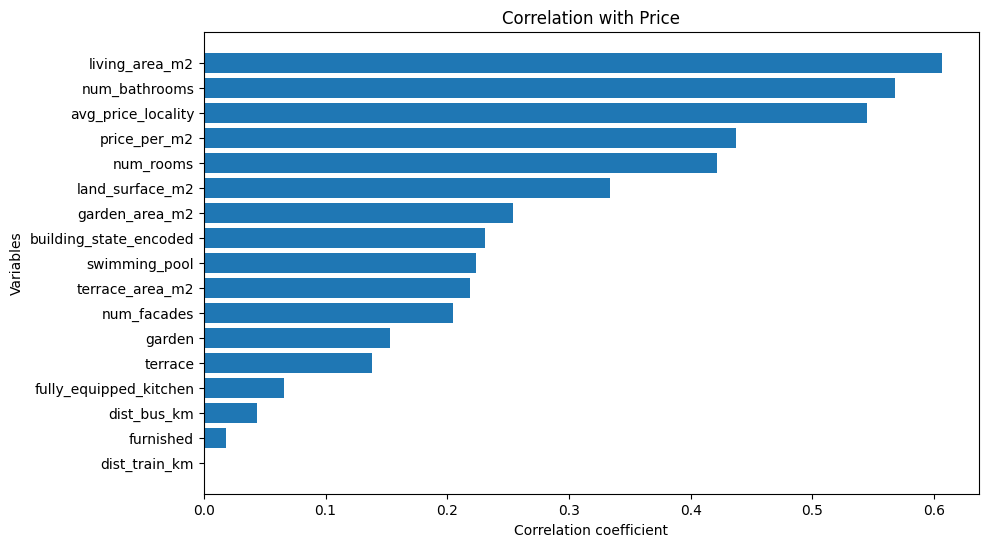

In [8]:
corr = (
    df.select_dtypes(include="number")
    .drop(columns=["postal_code"])
    .corr()["price_eur"]
    .drop("price_eur")
    .sort_values()
)

plt.figure(figsize=(10, 6))
plt.barh(corr.index, corr.values)
plt.title("Correlation with Price")
plt.xlabel("Correlation coefficient")
plt.ylabel("Variables")
plt.show()

How are variables correlated to each other? (Why?)

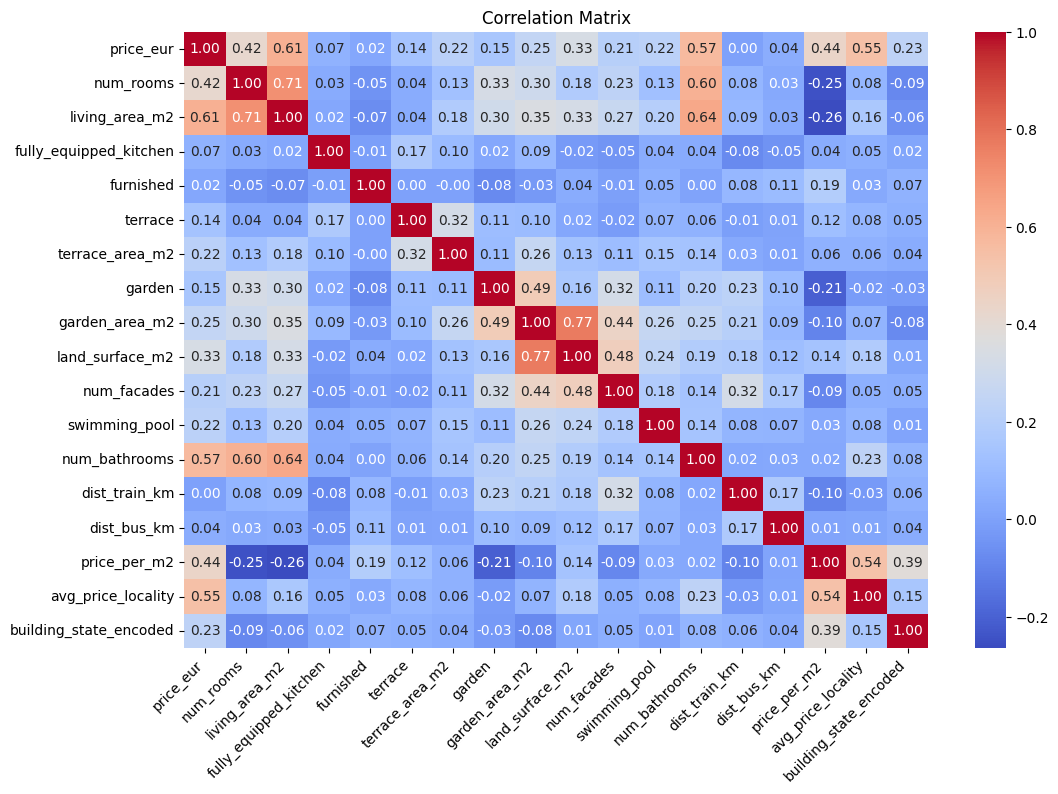

In [9]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    df.select_dtypes(include="number").drop(columns=["postal_code"]).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
)
plt.title("Correlation Matrix")
plt.xticks(rotation=45, ha="right")
plt.show()

## Correlation Analysis

### Strongest correlations with price:
- Living area and location have nearly the same strong correlation. as expected these two are the most important ones. In third comes number of rooms but thats related to living area.
- Furnished and kitchen state have the lowest correlation with the price. People seems to care less about these two.
### Interesting correlations between variables:
- Garden and number of facades seems to be strong related because properties with garden tend to be villas with 4 facades.
- Furnished has nearly 0 correlation with everything because is a personal choice and has nothing to do with the properties physical characteriscs.
- Building state and price only .2 This tells us that a run down villa in Brussels can still be more expensive than renovated one in rural areas. Location and size are more important than the property state.

### Weak/no correlations:
- Kitchen state seems to be weak with relation to everything else. It might be because we had a lot of properties without that information, but looking at furnished that is also weak it means that it remains a personal choice.

### Conclusions:
- When it comes to properties prices in Belgium the most important characteristics are size and location. No matter what state is the building or if it's furnished or not.

Percentage of missing values per column?

In [10]:
df.isnull().mean() * 100

locality                   0.000000
property_type              0.000000
subtype                    0.000000
price_eur                  0.000000
type_of_sale               0.000000
num_rooms                  1.541575
living_area_m2             0.000000
fully_equipped_kitchen     0.000000
furnished                 38.875253
terrace                    0.000000
terrace_area_m2           32.437670
garden                     0.000000
garden_area_m2            33.828532
land_surface_m2           48.374456
num_facades               22.860957
swimming_pool              0.000000
state_of_building         20.918917
num_bathrooms             26.874220
dist_train_km              4.818499
dist_bus_km                1.235844
price_per_m2               0.000000
postal_code                0.000000
region                     0.000000
outlier_flag               0.000000
avg_price_locality         0.000000
building_state_encoded    20.918917
dtype: float64

### Plot the outliers.


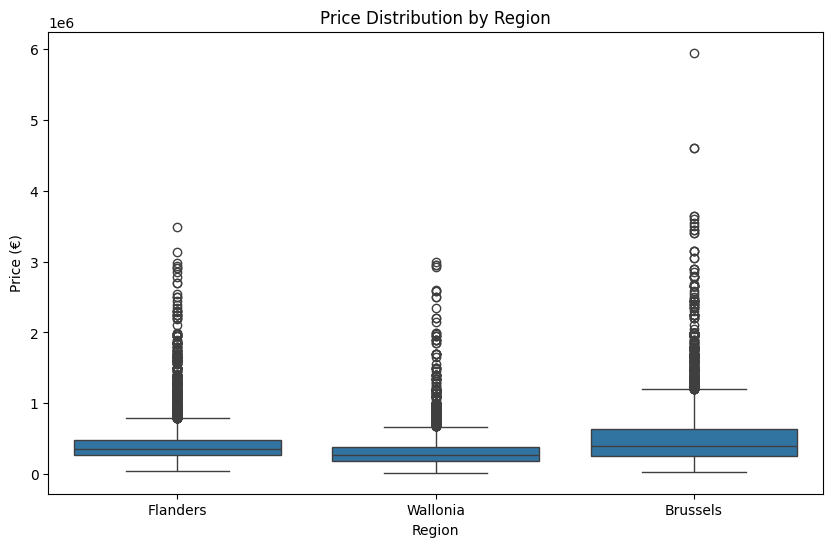

In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="region", y="price_eur")
plt.title("Price Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Price (€)")
plt.show()

### Observation
- Brussels has the highest median price followed closely by Flanders.
- Wallonia has the lowest median price
- Brussels has the widest box which means that prices vary more. It has a greater price variability
- All regions have many high price outliers but Brussels has the most extreme ones reaching nearly 6 million.

### What we get from this?
- We have a strong luxury market in Brussels that can be also diplomatic properties which make the price go higher.
- The lowest median price that is in Wallonia might be because it has more rural areas.
- Flanders is the most industrialized region, for this reason, the median price is higher than wallonia. Another reason is that Flanders has the most number of tourists with 63% of total overnight stays.

Represent the number of properties according to their surface using a histogram.

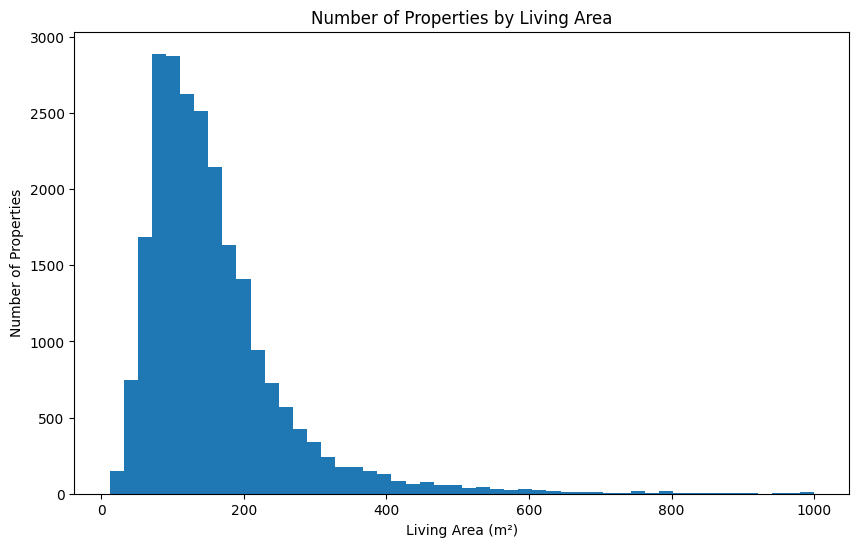

In [12]:
plt.figure(figsize=(10, 6))
plt.hist(df["living_area_m2"].dropna(), bins=50)
plt.title("Number of Properties by Living Area")
plt.xlabel("Living Area (m²)")
plt.ylabel("Number of Properties")
plt.show()

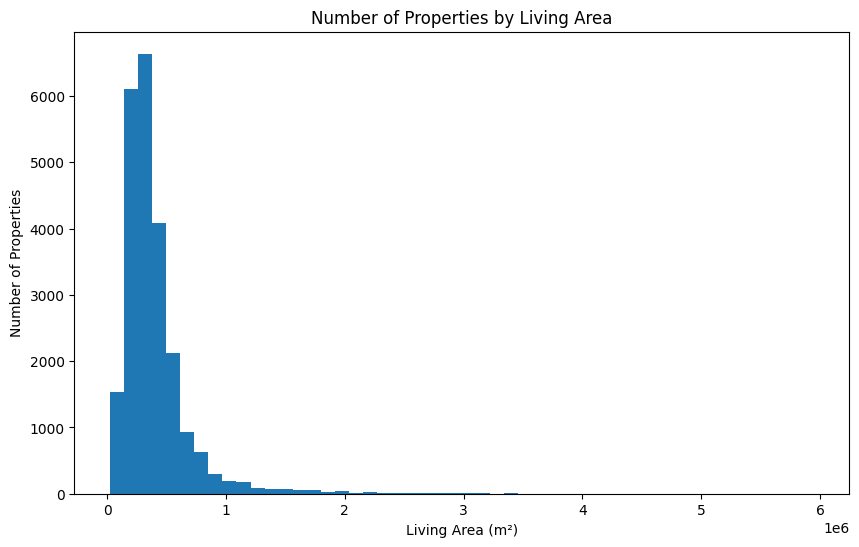

In [13]:
plt.figure(figsize=(10, 6))
plt.hist(df["price_eur"].dropna(), bins=50)
plt.title("Number of Properties by Living Area")
plt.xlabel("Living Area (m²)")
plt.ylabel("Number of Properties")
plt.show()

### What we get ?
We see that most of the properties are between 100-150 m2. This is the sweet spot between affordable and comfortable. Also the typical Belgian family is 2 - 4 persons, so developers build more properties in this range because they sell faster.

### Which 5 variables are the most important and why?

In my opinion 5 most important variables based also in the analysis that we did are:
- Living area (directly determines how much space you get for your money)
- Locality (closer to big cities the higher the price will be)
- Number of rooms (a family of 4 will prefer a property divided in at least 3 rooms even if the living area might be the same as a 1 room property. More rooms > Higher Price)
- Land surface (bigger land surface means more privacy and better opportunities to upgrade in the future)
- State of the building (better state of the building is directly connected to the total price you will have to pay. Also you can occupy that property faster without waiting for the renovation to finish first)

In our correlation chart we see that area of the garden is more correlated with the price than the state of the building. This doesn't indicate that the state of the building is less important but because garden area is strongly connected with land surface it makes it to stand higher in our chart.



What are the most expensive municipalities in Belgium? (Average price, median price, price per square meter)

In [14]:
#AVERAGE price per municipaltiy
df.groupby('locality')['price_eur'].agg(['mean', 'count']).query('count >= 10').sort_values('mean', ascending=False).head(10).round(2) #check the mean for at least 10 lisitngs

,mean,count
locality,,
1421 Ophain-Bois-Seigneur-Isaac,1255850.00,10
1950 Kraainem,1092028.57,35
8300 Knokke,1056910.26,39
1933 Sterrebeek,1049676.47,34
1150 Sint-Pieters-Woluwe,848242.77,173
1640 Sint-Genesius-Rode,840120.69,58
8300 Knokke-Heist,831393.86,57
3080 Tervuren,819924.84,31
2970 Schilde,791154.08,13


In [15]:
#MEDIAN price per municipaltiy
df.groupby('locality')['price_eur'].agg(['median', 'count']).query('count >= 10').sort_values('median', ascending=False).head(10).round(2)

,median,count
locality,,
1950 Kraainem,995000.0,35
1933 Sterrebeek,849500.0,34
1421 Ophain-Bois-Seigneur-Isaac,800000.0,10
8300 Knokke-Heist,795000.0,57
8300 Knokke,795000.0,39
1380 Lasne,695000.0,49
1325 Chaumont-Gistoux,695000.0,28
1970 Wezembeek-Oppem,685000.0,24
1150 Sint-Pieters-Woluwe,685000.0,173


In [16]:
#PRICE per sqm
df.groupby('locality')['price_per_m2'].agg(['median', 'count']).query('count >= 10').sort_values('median', ascending=False).head(10).round(2)

,median,count
locality,,
8300 Knokke,8529.41,39
8300 Knokke-Heist,7752.81,57
8301 Duinbergen,6684.78,47
9830 Sint-Martens-Latem,5432.69,13
3000 Leuven,5024.27,52
1160 Oudergem,4890.04,132
8620 Nieuwpoort,4727.58,106
1200 Sint-Lambrechts-Woluwe,4582.35,295
1050 Elsene,4503.34,392


In [17]:
# all three queries in one table
df.groupby("locality").agg(
    avg_price=("price_eur", "mean"),
    median_price=("price_eur", "median"),
    price_per_m2=("price_per_m2", "median"),
    count=("price_eur", "count"),
).query("count >= 10").sort_values("avg_price", ascending=False).head(10).round(2)

,avg_price,median_price,price_per_m2,count
locality,,,,
1421 Ophain-Bois-Seigneur-Isaac,1255850.00,800000.0,3297.78,10
1950 Kraainem,1092028.57,995000.0,4087.45,35
8300 Knokke,1056910.26,795000.0,8529.41,39
1933 Sterrebeek,1049676.47,849500.0,4087.72,34
1150 Sint-Pieters-Woluwe,848242.77,685000.0,4011.63,173
1640 Sint-Genesius-Rode,840120.69,670000.0,3422.42,58
8300 Knokke-Heist,831393.86,795000.0,7752.81,57
3080 Tervuren,819924.84,678670.0,3434.07,31
2970 Schilde,791154.08,583980.0,3255.49,13


What are the most expensive municipalities in Wallonia? (Average price, median price, price per square meter)

In [18]:
df[df['region'] == 'Wallonia'].groupby('locality').agg(
    avg_price=('price_eur', 'mean'),
    median_price=('price_eur', 'median'),
    price_per_m2=('price_per_m2', 'median'),
    count=('price_eur', 'count')
).query('count >= 10').sort_values('avg_price', ascending=False).head(10).round(2)

,avg_price,median_price,price_per_m2,count
locality,,,,
1421 Ophain-Bois-Seigneur-Isaac,1255850.00,800000.0,3297.78,10
1380 Lasne,739487.41,695000.0,3316.67,49
1310 La Hulpe,717562.50,559500.0,3038.89,16
6210 Les Bons Villers,691178.50,364376.0,2443.26,10
1325 Chaumont-Gistoux,669706.75,695000.0,3169.23,28
1410 Waterloo,657170.00,545000.0,3423.91,125
1420 Braine-l'Alleud,636935.69,495000.0,3180.00,77
1332 Genval,610800.00,535000.0,3312.50,25
1390 Grez-Doiceau,596597.55,412500.0,2872.28,38


What are the most expensive municipalities in Flanders? (Average price, median price, price per square meter)

In [19]:
df[df['region'] == 'Flanders'].groupby('locality').agg(
    avg_price=('price_eur', 'mean'),
    median_price=('price_eur', 'median'),
    price_per_m2=('price_per_m2', 'median'),
    count=('price_eur', 'count')
).query('count >= 10').sort_values('avg_price', ascending=False).head(10).round(2)

,avg_price,median_price,price_per_m2,count
locality,,,,
1950 Kraainem,1092028.57,995000.0,4087.45,35
8300 Knokke,1056910.26,795000.0,8529.41,39
1933 Sterrebeek,1049676.47,849500.0,4087.72,34
1640 Sint-Genesius-Rode,840120.69,670000.0,3422.42,58
8300 Knokke-Heist,831393.86,795000.0,7752.81,57
3080 Tervuren,819924.84,678670.0,3434.07,31
2970 Schilde,791154.08,583980.0,3255.49,13
1970 Wezembeek-Oppem,755083.33,685000.0,3807.26,24
2840 Rumst,750871.70,367000.0,3159.56,10


What are the less expensive municipalities in Belgium? (Average price, median price, price per square meter)

In [20]:
df.groupby("locality").agg(
    avg_price=("price_eur", "mean"),
    median_price=("price_eur", "median"),
    price_per_m2=("price_per_m2", "median"),
    count=("price_eur", "count"),
).query("count >= 10").sort_values("avg_price", ascending=True).head(10).round(2)

,avg_price,median_price,price_per_m2,count
locality,,,,
5542 Blaimont,86113.64,66750.0,1574.07,22
5540 Hastière-Lavaux,92864.29,86950.0,1449.16,14
6020 Dampremy,123316.58,97000.0,1011.44,12
7340 Colfontaine,145117.24,139000.0,1000.00,29
7370 Élouges,150408.33,110000.0,984.90,12
7390 Quaregnon,153454.50,137500.0,1151.51,22
6030 Marchienne-au-Pont,158480.33,159499.5,968.48,36
4102 Ougrée,158710.00,172000.0,1554.63,30
7012 Jemappes,168281.25,150000.0,1217.88,16


What are the less expensive municipalities in Wallonia? (Average price, median price, price per square meter)

In [21]:
df[df['region'] == 'Wallonia'].groupby('locality').agg(
    avg_price=('price_eur', 'mean'),
    median_price=('price_eur', 'median'),
    price_per_m2=('price_per_m2', 'median'),
    count=('price_eur', 'count')
).query('count >= 10').sort_values('avg_price', ascending=True).head(10).round(2)

,avg_price,median_price,price_per_m2,count
locality,,,,
5542 Blaimont,86113.64,66750.0,1574.07,22
5540 Hastière-Lavaux,92864.29,86950.0,1449.16,14
6020 Dampremy,123316.58,97000.0,1011.44,12
7340 Colfontaine,145117.24,139000.0,1000.00,29
7370 Élouges,150408.33,110000.0,984.90,12
7390 Quaregnon,153454.50,137500.0,1151.51,22
6030 Marchienne-au-Pont,158480.33,159499.5,968.48,36
4102 Ougrée,158710.00,172000.0,1554.63,30
7012 Jemappes,168281.25,150000.0,1217.88,16


What are the less expensive municipalities in Flanders? (Average price, median price, price per square meter)

In [22]:
df[df['region'] == 'Flanders'].groupby('locality').agg(
    avg_price=('price_eur', 'mean'),
    median_price=('price_eur', 'median'),
    price_per_m2=('price_per_m2', 'median'),
    count=('price_eur', 'count')
).query('count >= 10').sort_values('avg_price', ascending=True).head(10).round(2)

,avg_price,median_price,price_per_m2,count
locality,,,,
8890 Moorslede,203461.54,165000.0,1578.95,13
8940 Wervik,209230.88,205000.0,1080.64,26
3890 Gingelom,221916.67,204500.0,1202.56,12
3690 Zutendaal,249410.00,255000.0,1967.99,14
8430 Middelkerke,249768.18,242000.0,3980.33,22
2140 Borgerhout,256058.33,239000.0,2554.18,48
8930 Menen,259105.56,204000.0,1219.76,36
8930 Rekkem,260928.57,279000.0,1776.76,14
3700 Berg,261304.76,249000.0,1705.20,21
